# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Custodio, Neil Matthew
- _Student No._: 2024-14318
- _Section_: THR-TX-2

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![Wave_Interference_Figure](CUSTODIO_WaveInterference.pdf)

Figure 1. Wave Interference From Different Number of Point Sources

The following figure is what was produced using matplotlib and the given wavefunction model equation. The figures were made to share the same colorbar so that you can compare how the darkest sections on the left are less dark than the darkest sections on the right, this is due to the constructive interference being greater because there are more point sources. This is a model of objects falling in a basin so the colorbar represents the 'surface displacement' of the water.

### Problem 2

#### (i) For larger matrices, which is preffered, the custom `matrix_multiply()` or the `@` operator? Why?
The `@` operator is preffered, as matrix size grows the time it takes for the program to run grows as well, We run a test and take the average over trials to see just how much time it actually takes and the `@` operator runs significantly faster than the custom `matrix_multiply()` function I have designed. The custom function has to actively iterate through each element over the multiple for loops used in the other functions defined that were called inside of the `matrix_multiply()` function as well.
#### (ii) What are the general benefits of writing idiomatic Python?
Python is already a language that feels like pseudocode that can run, idiomatic Python allows for this pseudocode to be easier to read.

### Other comments
- I lack practice in using matplotlib, I need to get used to not looking at the documentation to know what parameters I need to put


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

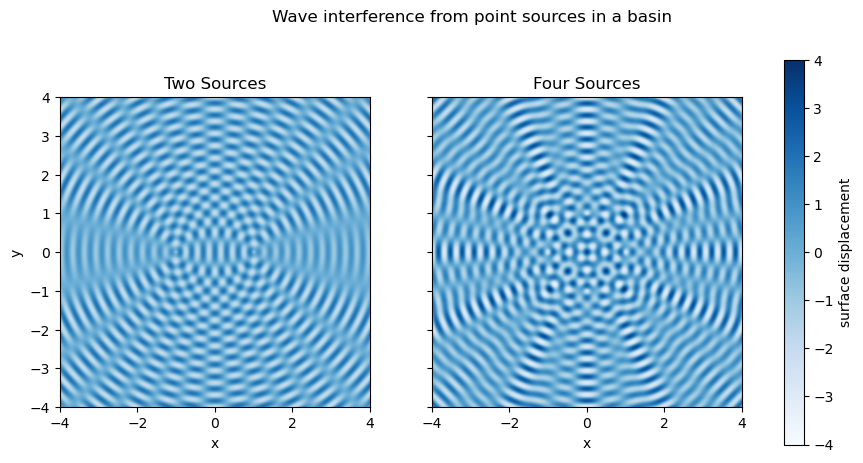

In [1]:
import matplotlib.pyplot as plt
import numpy as np

A = 1
k = (2*np.pi)/0.3

def W(x,y,r):
    func = np.zeros_like(x,dtype=float)
    for source in r:
        wave = A*np.sin(k*np.sqrt((x-source[0])**2+(y-source[1])**2))
        func = func + wave
    return func

x = np.linspace(-4,4,800)
y = np.linspace(-4,4,800)
X,Y = np.meshgrid(x,y)

fig, (ax1,ax2) = plt.subplots(1,2,figsize = (11,5), sharey=True)
extent = [x.min(),x.max(),y.min(),y.max()]

r2 = [[-1,0],
      [1,0]]
Z2 = W(X,Y,r2)
ax1.imshow(Z2, extent=extent, origin="lower",cmap="Blues",interpolation="bilinear",vmin=-4,vmax=4)
ax1.set_title('Two Sources')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

r4 = [[-1,0],
      [1,0],
      [0,-1],
      [0,1]]
Z4 = W(X,Y,r4)
im2 = ax2.imshow(Z4, extent=extent, origin="lower",cmap="Blues",interpolation="bilinear",vmin=-4,vmax=4)
ax2.set_title('Four Sources')
ax2.set_xlabel('x')

fig.colorbar(im2, ax=[ax1,ax2], label='surface displacement')
fig.suptitle('Wave interference from point sources in a basin')

plt.show()

#### Problem 1 code summary

The following program plots the expected result when objects drop into a water basin to model what that interference may look like. The function W(X,Y,r) is used to receive the coordinate grid that was produced using linspace and meshgrid AND the positions of the point sources, then it returns the superposition of the wavefunctions produced. The use of list of lists for the point sources allows for easier set up than typing the entire `A*np.sin(k*np.sqrt((x-source[0])**2+(y-source[1])**2))` for each point source

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [2]:
import random

In [3]:
random.seed(14)
random.randint(1,9)

2

In [4]:
import random
number = random.randint(1, 9)
number

9

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [5]:
def random_integer_matrix(nrows, ncols):
    '''
    List Comprehension
    generates a random integer from 1 to 9
    it goes through each element in the following order if it is a 2x2 matrix
    1 2
    3 4
    then for 3x2
    1 2
    3 4
    5 6
    then for 2x3
    1 2 3
    4 5 6
    '''

    # matrix = []
    # for row in range(nrows):
    #    matrix.append([])
    #    for column in range(ncols):
    #        matrix[row].append(random.randint(1,9))
    # return matrix
    
    return [[random.randint(1,9) for column in range(ncols)] for row in range(nrows)]
random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[4, 5, 5, 5], [2, 8, 5, 8], [7, 7, 2, 5]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [6]:
def scalar_product(list1,list2):
    if len(list1) != len(list2):
        return "Incompatible List Lengths: cannot perform scalar product"
    else:
        sum = 0 #initializes sum value to be at 0
        # for i in range(len(list1)):
        #     sum = sum + list1[i]*list2[i] adds the product of elements at the same index to the current value of sum
        
        product = [sum:=sum+list1[i]*list2[i] for i in range(len(list1))] # list comprehension version
        return sum

In [7]:
print(scalar_product([1,1,1,4],[1,2,3]))
print(scalar_product([1,2,3],[3,2,1]))

Incompatible List Lengths: cannot perform scalar product
10


c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [8]:
def transpose_matrix(orig_matrix):
    nrows = len(orig_matrix)
    ncols = len(orig_matrix[0])

    # transposed = [] creates a blank matrix
    # for i in range(ncols): goes through each row but uses the range of number of columns
    #     transposed.append([])
    #     for j in range(nrows): goes through each column but uses the range of number of rows
    #         transposed[i].append(orig_matrix[j][i]) uses the idea that the ij-th element is just the ji-th element when transposed
    # return transposed
    return [[orig_matrix[j][i] for j in range(nrows)] for i in range(ncols)]

In [9]:
matrix_sample = random_integer_matrix(3,4)
print('Original Matrix',matrix_sample)
print('Transpose Matrix',transpose_matrix(matrix_sample))

Original Matrix [[4, 6, 6, 5], [6, 9, 3, 3], [9, 5, 3, 1]]
Transpose Matrix [[4, 6, 9], [6, 9, 5], [6, 3, 3], [5, 3, 1]]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [10]:
def matrix_multiply(left_matrix, right_matrix):
    if len(left_matrix[0]) != len(right_matrix):
        return 'Incompatible Matrix Size: cannot perform matrix multiplication'
    else:
        multiple = transpose_matrix(right_matrix)
        newrows = len(left_matrix)
        newcols = len(right_matrix[0])
        # multiplied = []
        # for i in range(newrows):
        #    multiplied.append([])
        #    for j in range(newcols):
        #        multiplied[i].append(scalar_product(left_matrix[i],multiple[j]))
        # return multiplied
        return [[scalar_product(left_matrix[row],multiple[col]) for col in range(newcols)] for row in range(newrows)]

In [11]:
matrixC = random_integer_matrix(2,1) 
matrixD = random_integer_matrix(5,1)
print(matrix_multiply(matrixC,matrixD))

Incompatible Matrix Size: cannot perform matrix multiplication


In [12]:
matrixE = random_integer_matrix(2,3)
matrixF = random_integer_matrix(3,4)
print('Left Matrix',matrixE)
print('Right Matrix',matrixF)
print('Matrix Product',matrix_multiply(matrixE,matrixF))

Left Matrix [[7, 7, 8], [2, 2, 6]]
Right Matrix [[3, 2, 8, 9], [4, 5, 8, 4], [8, 5, 9, 5]]
Matrix Product [[113, 89, 184, 131], [62, 44, 86, 56]]


#### Problem 2 code summary

The end goal of the program is to provide a matrix product given two matrices, left and right. The logic used for the `random_integer_matrix()` function provided a for loop format that would end up being used for the transposition and multiplication functions as well. I ended up writing each using the for loop then converting into list comprehension for better readability.

### Timing the Difference

In [13]:
import random, time
import numpy as np

def time_it(func, trials=10):
    times = []
    for _ in range(trials):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / trials

for n in [10, 50, 100, 200, 400]:
    A = random_integer_matrix(n, n)
    B = random_integer_matrix(n, n)
    npA, npB = np.array(A), np.array(B)

    t_custom = time_it(lambda: matrix_multiply(A, B))
    t_numpy  = time_it(lambda: npA @ npB)

    print(f"n={n:4d}  custom={t_custom:.6f}s  @={t_numpy:.6f}s")

n=  10  custom=0.000080s  @=0.000004s
n=  50  custom=0.006441s  @=0.000068s
n= 100  custom=0.049272s  @=0.000502s
n= 200  custom=0.386450s  @=0.004452s
n= 400  custom=2.953672s  @=0.034054s
